<a href="https://colab.research.google.com/github/ggalanc/proyecto_dengue/blob/main/notebooks/practico_06_proyecto_final_f0_f1_eda_Gerardo_Galan_Mabel_Herrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Práctico Final: MLOps Local con Monitoreo de Data Drift
## Fases 0 y 1 — Problemática, EDA y Detección de Fuga de Datos Potencial
### Magíster en Ciencia de Datos — Tópicos en Data Science II
---

**Integrantes:** Gerardo Galán - Mabel Herrera

**Dataset:** DengAI — Predicción de casos de dengue en San Juan (Puerto Rico) e Iquitos (Perú)
(fuente: [DrivenData / Kaggle `arashnic/epidemy`](https://www.kaggle.com/datasets/arashnic/epidemy))

---

## Objetivo de este notebook

Al finalizar estas dos fases seremos capaces de:

1. Justificar **por qué el dengue es un problema donde el monitoreo de drift es crítico** (RAA5).
2. Ejecutar un **EDA riguroso** sobre datos climático-epidemiológicos con estructura temporal (RAA2), reutilizando los criterios de calidad y de análisis multivariado de los Prácticos 1, 3 y 4.
3. Identificar explícitamente **riesgos de fuga de datos** propios de este dataset, para que el pipeline de modelado de la Fase 2 los evite desde el diseño.


---
## 🔧 Bootstrap para Google Colab

Esta celda trae el proyecto completo (código en `src/`, `service/`, datos y modelo ya entrenado) al entorno de Colab, que empieza vacío en cada sesión. Si `REPO_URL` está vacío, la celda ofrece subir un `.zip` del repositorio en su lugar.

**No hace falta editar nada más de este notebook** — el resto de las celdas ya usan rutas relativas (`../data/`, `../models/`, etc.) que funcionan igual aquí que en una máquina local, una vez que el directorio de trabajo queda en `notebooks/`.


In [ ]:
# ── Bootstrap para Google Colab: trae el repositorio a este entorno ──
import os

REPO_URL = "https://github.com/ggalanc/proyecto_dengue.git"
REPO_DIR = "/content/dengue_mlops_drift_repo_1"

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB and not os.path.exists(REPO_DIR):
    if REPO_URL:
        print("Clonando repositorio...")
        get_ipython().system('git clone -q "{}" "{}"'.format(REPO_URL, REPO_DIR))
    else:
        print("REPO_URL esta vacio. Selecciona el .zip del repositorio para subirlo:")
        from google.colab import files
        subido = files.upload()
        zip_name = list(subido.keys())[0]
        os.makedirs(REPO_DIR, exist_ok=True)
        get_ipython().system('unzip -q "{}" -d "{}"'.format(zip_name, REPO_DIR))
        contenido = os.listdir(REPO_DIR)
        if len(contenido) == 1 and os.path.isdir(os.path.join(REPO_DIR, contenido[0])):
            sub = os.path.join(REPO_DIR, contenido[0])
            for item in os.listdir(sub):
                os.rename(os.path.join(sub, item), os.path.join(REPO_DIR, item))
            os.rmdir(sub)

if IN_COLAB:
    os.chdir(os.path.join(REPO_DIR, "notebooks"))
    print("Directorio de trabajo:", os.getcwd())
else:
    print("No se detecto Colab -- se asume ejecucion local normal, sin cambios de directorio.")


---
## Fase 0 — Problemática y justificación de negocio

### Contexto

Los servicios de salud pública de San Juan (Puerto Rico) e Iquitos (Perú) necesitan anticipar brotes de dengue con semanas de antelación para poder actuar: reforzar fumigación, campañas de eliminación de criaderos de mosquitos y capacidad hospitalaria. Un modelo que prediga `total_cases` (casos semanales de dengue) a partir de variables climáticas (temperatura, humedad, precipitación, vegetación vía NDVI) permite priorizar recursos **antes** de que el brote sea evidente en las urgencias.

### Por qué este caso es relevante para *data drift* y *concept drift*

> **Párrafo de justificación (para el Informe Ejecutivo):** El dengue es un caso de libro para el monitoreo de drift porque la relación entre clima y transmisión **no es estática**: el dataset abarca 1990–2010 (San Juan) y 2000–2010 (Iquitos), un período que incluye eventos El Niño/La Niña de distinta intensidad, cambios en la variabilidad climática y, muy probablemente, cambios no observados en el vector (mosquito *Aedes aegypti*), en la inmunidad de la población y en las políticas de control vectorial de cada ciudad. Esto produce **tanto data drift** (la distribución de temperatura, humedad y precipitación se desplaza de década en década, y ya difiere estructuralmente entre San Juan e Iquitos) **como concept drift** (la fuerza de la relación clima→casos cambia: como se muestra en el EDA, en San Juan la correlación climática es más fuerte con 8–12 semanas de rezago, mientras que en Iquitos el efecto es casi inmediato y se diluye con el rezago, evidencia de que el mecanismo de transmisión no es idéntico ni estable entre poblaciones). Un modelo entrenado con los años 1990s y nunca reevaluado corre un riesgo concreto de degradarse silenciosamente frente a un año con un patrón climático atípico (un El Niño fuerte, por ejemplo), justo cuando más se necesita que funcione bien.

### Tabla RAA de esta entrega (fases 0-1)

| RAA | Cómo se evalúa en este notebook |
|---|---|
| RAA5 — Identificar problemáticas abordables con CD | Fase 0: elección y justificación del caso (arriba) |
| RAA2 — Exploración de datos | Fase 1: EDA univariado/multivariado + detección de fuga potencial (todo lo que sigue) |



---
## Setup — Librerías y carga de datos

**Nota sobre la fuente de datos:** el enunciado sugiere descargar el dataset con `kagglehub` (`kagglehub.dataset_download("arashnic/epidemy")`). Para que el proyecto cumpla el requisito de **ejecutarse en <10 minutos con un solo comando y sin depender de credenciales externas**, los 4 CSV del dataset se incluyen directamente en `data/raw/` del repositorio. La celda de carga intenta primero esa ruta local y, solo si no la encuentra, cae de vuelta a `kagglehub` como alternativa reproducible.


In [1]:
# ── Importaciones ──
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

RANDOM_STATE = 42
DATA_DIR = '../data/raw/'

print("Librerías cargadas")


Librerías cargadas


In [2]:
# ── Carga robusta del dataset (local primero, kagglehub como respaldo) ──

def _cargar_datos(data_dir):
    archivos = ['dengue_features_train.csv', 'dengue_labels_train.csv',
                'dengue_features_test.csv', 'submission_format.csv']
    if all(os.path.exists(os.path.join(data_dir, a)) for a in archivos):
        return data_dir
    return None

ruta = _cargar_datos(DATA_DIR)

if ruta is None:
    # Alternativa dada en el enunciado: descarga vía kagglehub
    import kagglehub
    print("No se encontraron los CSV localmente, descargando con kagglehub...")
    ruta = kagglehub.dataset_download("arashnic/epidemy")
    print("Path to dataset files:", ruta)
else:
    print(f"Datos encontrados localmente en: {ruta}")

feat_train = pd.read_csv(os.path.join(ruta, 'dengue_features_train.csv'), parse_dates=['week_start_date'])
lab_train  = pd.read_csv(os.path.join(ruta, 'dengue_labels_train.csv'))
feat_test  = pd.read_csv(os.path.join(ruta, 'dengue_features_test.csv'), parse_dates=['week_start_date'])
sub_format = pd.read_csv(os.path.join(ruta, 'submission_format.csv'))

# Dataset maestro de entrenamiento: features + target, alineados por (city, year, weekofyear)
df = feat_train.merge(lab_train, on=['city', 'year', 'weekofyear'], how='inner')

print(f"\nfeat_train: {feat_train.shape}  |  lab_train: {lab_train.shape}  |  df (merge): {df.shape}")
print(f"feat_test (sin target, uso Kaggle):  {feat_test.shape}")
assert len(df) == len(feat_train), "El merge perdió filas: revisar alineación city/year/weekofyear"
df.head()


No se encontraron los CSV localmente, descargando con kagglehub...


100%|██████████| 119k/119k [00:00<00:00, 292kB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arashnic/epidemy/versions/1

feat_train: (1456, 24)  |  lab_train: (1456, 4)  |  df (merge): (1456, 25)
feat_test (sin target, uso Kaggle):  (416, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.123,0.104,0.198,0.178,12.420,297.573,297.743,292.414,299.800,295.900,32.000,73.366,12.420,14.013,2.629,25.443,6.900,29.400,20.000,16.000,4
1,sj,1990,19,1990-05-07,0.170,0.142,0.162,0.155,22.820,298.211,298.443,293.951,300.900,296.400,17.940,77.369,22.820,15.373,2.371,26.714,6.371,31.700,22.200,8.600,5
2,sj,1990,20,1990-05-14,0.032,0.173,0.157,0.171,34.540,298.781,298.879,295.434,300.500,297.300,26.100,82.053,34.540,16.849,2.300,26.714,6.486,32.200,22.800,41.400,4
3,sj,1990,21,1990-05-21,0.129,0.245,0.228,0.236,15.360,298.987,299.229,295.310,301.400,297.000,13.900,80.337,15.360,16.673,2.429,27.471,6.771,33.300,23.300,4.000,3
4,sj,1990,22,1990-05-28,0.196,0.262,0.251,0.247,7.520,299.519,299.664,295.821,301.900,297.500,12.200,80.460,7.520,17.210,3.014,28.943,9.371,35.000,23.900,5.800,6


---
## Paso 1 — Entender el grano de los datos y las preguntas analíticas

Cada fila es **una ciudad-semana**: `city` (`sj`=San Juan, `iq`=Iquitos), `year`, `weekofyear`, `week_start_date`, 20 variables climático-ambientales (temperatura, humedad, precipitación, NDVI) y el target `total_cases`.

| # | Pregunta de negocio | Cómo se responde en este EDA |
|---|---|---|
| 1 | ¿Cómo se distribuyen los casos de dengue por ciudad? ¿Es un problema de conteo raro o frecuente? | Univariado de `total_cases` |
| 2 | ¿Hay estacionalidad y outbreaks históricos identificables? | Serie de tiempo por ciudad |
| 3 | ¿Qué variables climáticas se asocian más con los casos, y con qué rezago? | Correlación con lags |
| 4 | ¿San Juan e Iquitos son la misma población estadística? | Comparación multivariada por ciudad |
| 5 | ¿Dónde están los riesgos de fuga de datos de este dataset en particular? | Sección dedicada al final |


---
## Paso 2 — Auditoría de calidad de datos

Reutilizamos el criterio del Práctico 2 (calidad de datos): nulos, tipos, duplicados, y si el patrón de nulos es aleatorio o tiene estructura (lo que importaría para decidir cómo imputar en el pipeline de la Fase 2).


In [3]:
# ── Auditoría de calidad ──
print("Tipos de datos:")
print(df.dtypes.value_counts())
print()
print("Filas duplicadas (city, year, weekofyear):", df.duplicated(subset=['city','year','weekofyear']).sum())
print()

num_cols = [c for c in df.columns if c not in ['city','year','weekofyear','week_start_date','total_cases']]
nulos = (df[num_cols].isna().mean() * 100).sort_values(ascending=False)
print("% de nulos por variable (todas < 15%, pero no aleatorias entre sí):")
print(nulos.round(2))


Tipos de datos:
float64           20
int64              3
object             1
datetime64[ns]     1
Name: count, dtype: int64

Filas duplicadas (city, year, weekofyear): 0

% de nulos por variable (todas < 15%, pero no aleatorias entre sí):
ndvi_ne                                 13.320
ndvi_nw                                  3.570
station_avg_temp_c                       2.950
station_diur_temp_rng_c                  2.950
ndvi_sw                                  1.510
ndvi_se                                  1.510
station_precip_mm                        1.510
station_max_temp_c                       1.370
station_min_temp_c                       0.960
precipitation_amt_mm                     0.890
reanalysis_sat_precip_amt_mm             0.890
reanalysis_air_temp_k                    0.690
reanalysis_relative_humidity_percent     0.690
reanalysis_precip_amt_kg_per_m2          0.690
reanalysis_min_air_temp_k                0.690
reanalysis_max_air_temp_k                0.690
reanaly

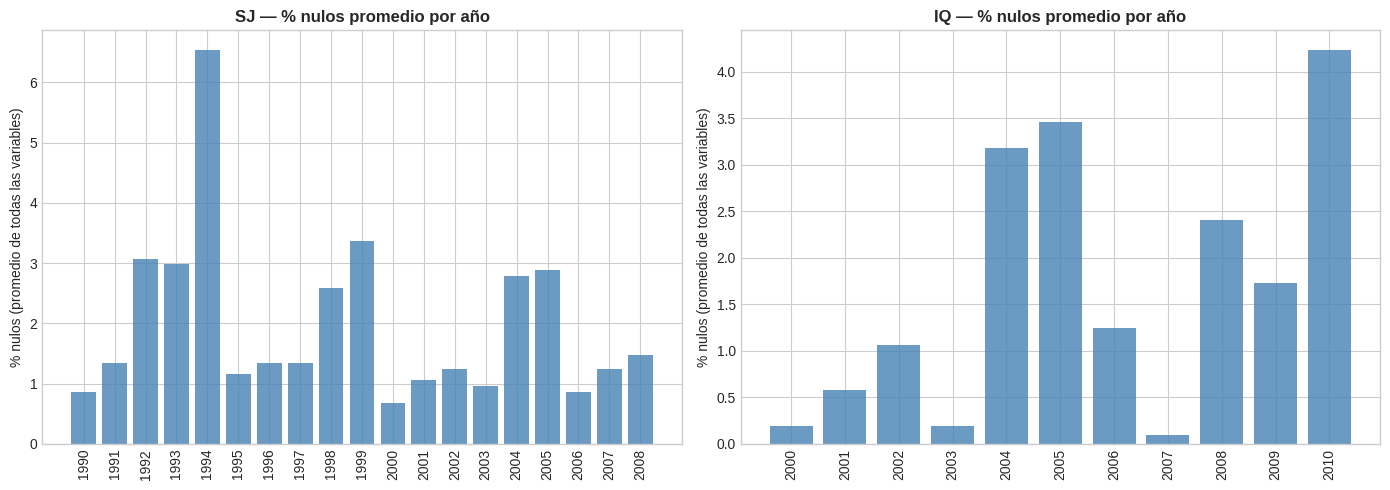

HALLAZGO: los nulos no son un fenómeno aleatorio ni constante — se concentran en años/
variables específicas (NDVI sobre todo). Esto importa para la Fase 2: una imputación con la
media GLOBAL de toda la serie filtraría información del futuro hacia el pasado (y viceversa);
la estrategia correcta es imputar con información disponible SOLO hasta ese punto en el tiempo
(ej. forward-fill dentro del pipeline, ajustado exclusivamente con el fold de entrenamiento).


In [4]:
# ── ¿El patrón de nulos cambia en el tiempo? (importa para decidir la estrategia de imputación) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, city in zip(axes, ['sj', 'iq']):
    sub = df[df['city'] == city].sort_values('week_start_date')
    tasa_nulos_anual = sub.groupby('year')[num_cols].apply(lambda x: x.isna().mean().mean() * 100)
    ax.bar(tasa_nulos_anual.index.astype(str), tasa_nulos_anual.values, color='steelblue', alpha=0.8)
    ax.set_title(f'{city.upper()} — % nulos promedio por año', fontweight='bold')
    ax.set_ylabel('% nulos (promedio de todas las variables)')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

print("HALLAZGO: los nulos no son un fenómeno aleatorio ni constante — se concentran en años/")
print("variables específicas (NDVI sobre todo). Esto importa para la Fase 2: una imputación con la")
print("media GLOBAL de toda la serie filtraría información del futuro hacia el pasado (y viceversa);")
print("la estrategia correcta es imputar con información disponible SOLO hasta ese punto en el tiempo")
print("(ej. forward-fill dentro del pipeline, ajustado exclusivamente con el fold de entrenamiento).")


---
## Paso 3 — Análisis univariado: la variable objetivo `total_cases`

### Teoría: por qué esto no es una regresión "normal"

`total_cases` es un **conteo** (no negativo, entero, con muchos valores bajos y una cola larga de brotes extremos). Esto tiene dos implicancias para la Fase 2:

- Un modelo de regresión lineal clásico no está bien especificado para conteos con esta asimetría; conviene un modelo robusto a colas largas (árboles/boosting) o una transformación del target.
- Las métricas de evaluación deben ser robustas a outliers (MAE) y no solo RMSE, porque unos pocos brotes masivos pueden dominar el error.


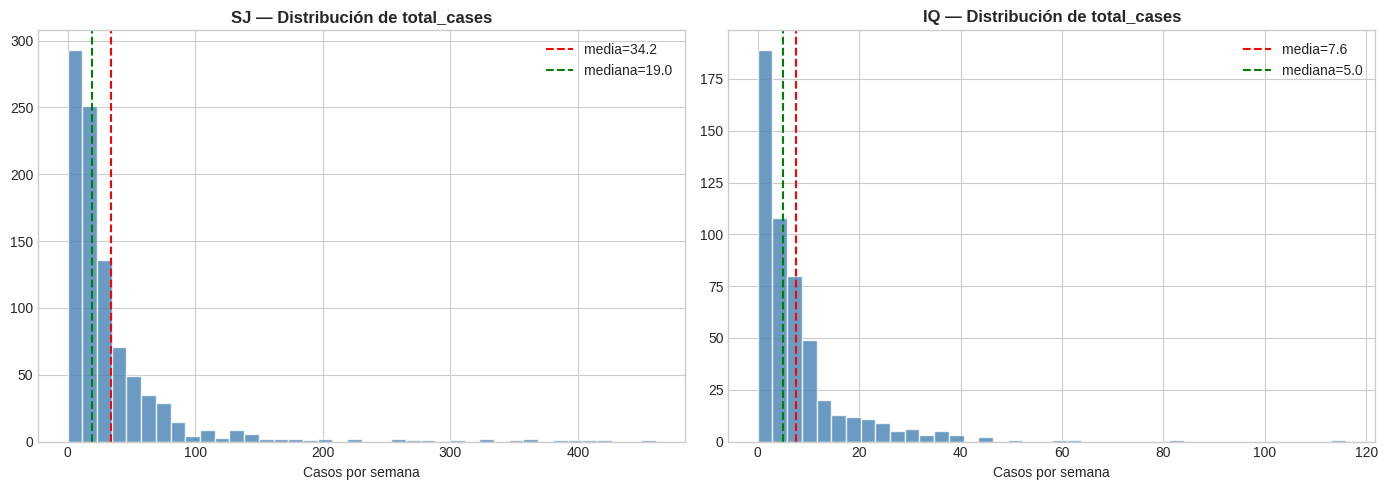

       mean  median    std  max  skew
city                                 
iq    7.570   5.000 10.770  116 4.000
sj   34.180  19.000 51.380  461 4.480

HALLAZGO: ambas ciudades tienen distribuciones fuertemente asimétricas a la derecha (skew ~4),
con la mediana muy por debajo de la media -> confirma que son semanas 'tranquilas' la norma y
los brotes son eventos extremos poco frecuentes pero de alto impacto (lo que además hace que el
desempeño del modelo en esas semanas de brote sea, precisamente, lo más importante de monitorear).


In [5]:
# ── Distribución de total_cases por ciudad ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city in zip(axes, ['sj', 'iq']):
    sub = df[df['city'] == city]
    ax.hist(sub['total_cases'], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(sub['total_cases'].mean(), color='red', linestyle='--', label=f"media={sub['total_cases'].mean():.1f}")
    ax.axvline(sub['total_cases'].median(), color='green', linestyle='--', label=f"mediana={sub['total_cases'].median():.1f}")
    ax.set_title(f'{city.upper()} — Distribución de total_cases', fontweight='bold')
    ax.set_xlabel('Casos por semana')
    ax.legend()

plt.tight_layout()
plt.show()

resumen_target = df.groupby('city')['total_cases'].agg(['mean','median','std','max','skew']).round(2)
print(resumen_target)
print("\nHALLAZGO: ambas ciudades tienen distribuciones fuertemente asimétricas a la derecha (skew ~4),")
print("con la mediana muy por debajo de la media -> confirma que son semanas 'tranquilas' la norma y")
print("los brotes son eventos extremos poco frecuentes pero de alto impacto (lo que además hace que el")
print("desempeño del modelo en esas semanas de brote sea, precisamente, lo más importante de monitorear).")


---
## Paso 4 — Series de tiempo: outbreaks históricos por ciudad

Visualizamos la serie completa para identificar los brotes históricos más severos — esto ya es, en sí mismo, un adelanto de por qué el drift importa: si el modelo solo ve años "normales" en entrenamiento, un año como estos será su primera prueba real en producción.


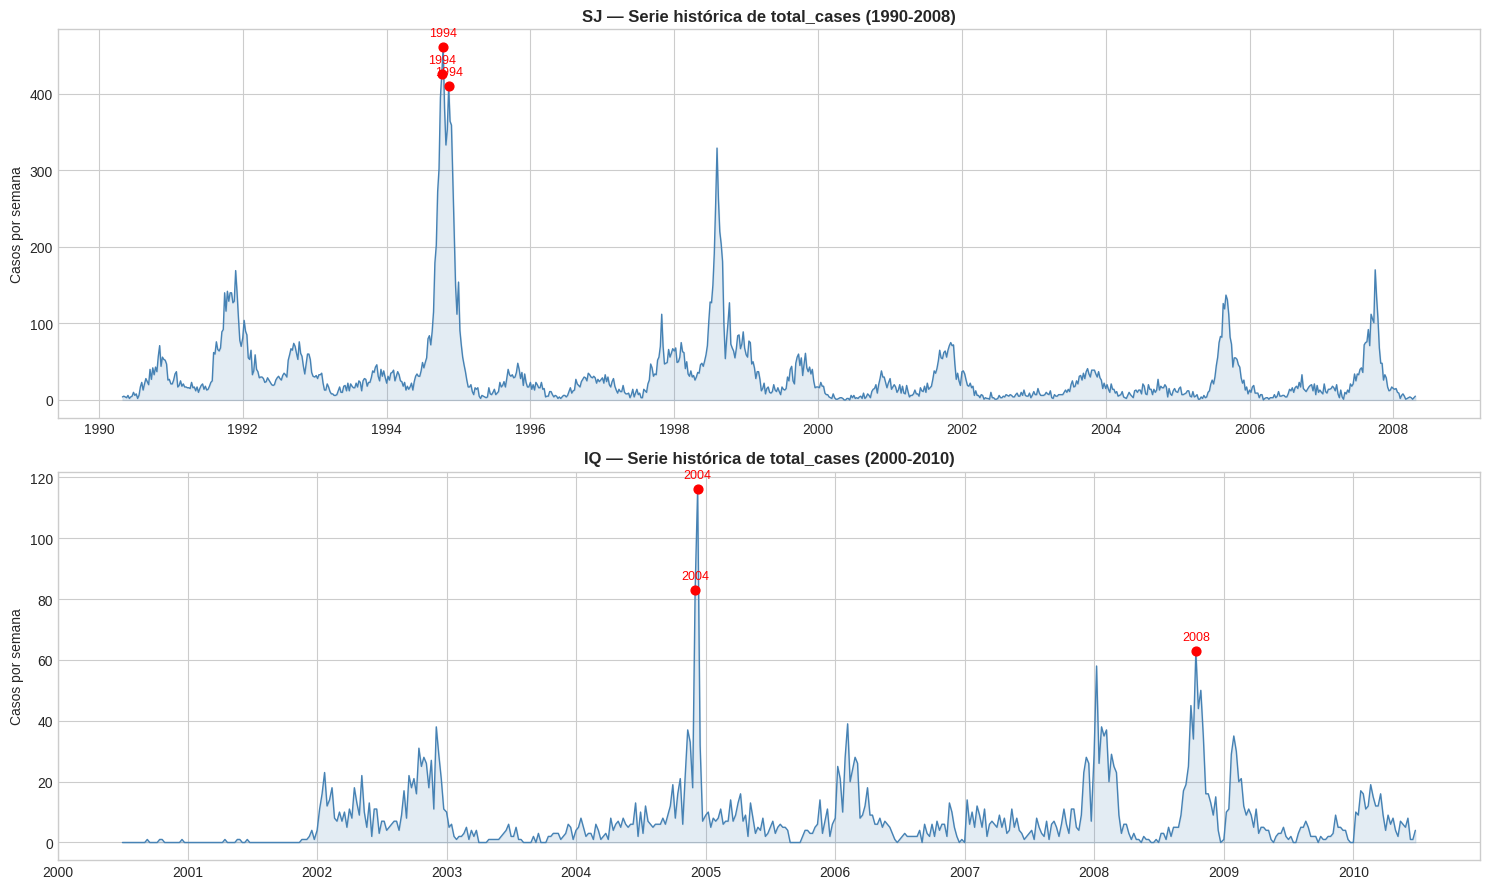


Top 3 semanas de outbreak — SJ:
 year  weekofyear  total_cases
 1994          41          461
 1994          40          426
 1994          45          410

Top 3 semanas de outbreak — IQ:
 year  weekofyear  total_cases
 2004          50          116
 2004          49           83
 2008          42           63

HALLAZGO: San Juan tuvo su outbreak histórico en 1994 (~460 casos/semana, ~10x su mediana),
Iquitos en 2004 (~116 casos/semana, ~23x su mediana). Ningún año 'normal' de entrenamiento
prepara al modelo para la magnitud de estos eventos -> son el caso de uso central de la Fase 4/5:
¿el sistema de monitoreo hubiera detectado que algo estaba cambiando ANTES del pico?


In [6]:
# ── Serie de tiempo completa por ciudad, con los 3 mayores outbreaks anotados ──
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

for ax, city in zip(axes, ['sj', 'iq']):
    sub = df[df['city'] == city].sort_values('week_start_date')
    ax.plot(sub['week_start_date'], sub['total_cases'], color='steelblue', linewidth=1)
    ax.fill_between(sub['week_start_date'], sub['total_cases'], alpha=0.15, color='steelblue')

    top3 = sub.nlargest(3, 'total_cases')
    ax.scatter(top3['week_start_date'], top3['total_cases'], color='red', zorder=5, s=40)
    for _, row in top3.iterrows():
        ax.annotate(f"{int(row['year'])}", (row['week_start_date'], row['total_cases']),
                    textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9, color='red')

    ax.set_title(f'{city.upper()} — Serie histórica de total_cases ({sub["year"].min()}-{sub["year"].max()})',
                 fontweight='bold')
    ax.set_ylabel('Casos por semana')

plt.tight_layout()
plt.show()

for city in ['sj', 'iq']:
    top3 = df[df['city']==city].nlargest(3, 'total_cases')[['year','weekofyear','total_cases']]
    print(f"\nTop 3 semanas de outbreak — {city.upper()}:")
    print(top3.to_string(index=False))

print("\nHALLAZGO: San Juan tuvo su outbreak histórico en 1994 (~460 casos/semana, ~10x su mediana),")
print("Iquitos en 2004 (~116 casos/semana, ~23x su mediana). Ningún año 'normal' de entrenamiento")
print("prepara al modelo para la magnitud de estos eventos -> son el caso de uso central de la Fase 4/5:")
print("¿el sistema de monitoreo hubiera detectado que algo estaba cambiando ANTES del pico?")


---
## Paso 5 — Análisis multivariado: clima vs. casos, y el rol del rezago (*lag*)

### Teoría: por qué el rezago importa biológicamente

El ciclo de transmisión del dengue no es instantáneo: after mayor humedad/temperatura, el mosquito *Aedes aegypti* necesita tiempo para reproducirse, el virus necesita un período de incubación extrínseco en el mosquito, y luego un período de incubación en el humano antes de que el caso se reporte. Por eso esperamos que la correlación climática sea más fuerte a varias semanas de rezago, no en la semana misma — y por eso el pipeline de la Fase 2 deberá construir **features de rezago (lag features)**, tema que retomamos en la sección de fuga de datos.


In [7]:
# ── Correlación de features climáticas con total_cases, a distintos rezagos (semanas) ──
key_feats = ['reanalysis_specific_humidity_g_per_kg', 'reanalysis_dew_point_temp_k',
             'station_avg_temp_c', 'precipitation_amt_mm',
             'reanalysis_precip_amt_kg_per_m2', 'ndvi_ne']

lags = [0, 2, 4, 8, 12]
tablas_lag = {}
for city in ['sj', 'iq']:
    sub = df[df['city'] == city].sort_values('week_start_date').reset_index(drop=True)
    filas = []
    for f in key_feats:
        fila = {'feature': f}
        for lag in lags:
            # feature en t vs. casos en t+lag: usamos shift(-lag) para "adelantar" los casos
            fila[f'lag_{lag}sem'] = sub[f].corr(sub['total_cases'].shift(-lag))
        filas.append(fila)
    tablas_lag[city] = pd.DataFrame(filas).set_index('feature')
    print(f"=== Correlación (Pearson) feature(t) vs. total_cases(t+lag) — {city.upper()} ===")
    print(tablas_lag[city].round(3))
    print()


=== Correlación (Pearson) feature(t) vs. total_cases(t+lag) — SJ ===
                                       lag_0sem  lag_2sem  lag_4sem  lag_8sem  \
feature                                                                         
reanalysis_specific_humidity_g_per_kg     0.208     0.250     0.281     0.302   
reanalysis_dew_point_temp_k               0.204     0.247     0.279     0.302   
station_avg_temp_c                        0.197     0.250     0.307     0.364   
precipitation_amt_mm                      0.060     0.084     0.072     0.064   
reanalysis_precip_amt_kg_per_m2           0.107     0.124     0.110     0.076   
ndvi_ne                                   0.038     0.037     0.039     0.050   

                                       lag_12sem  
feature                                           
reanalysis_specific_humidity_g_per_kg      0.257  
reanalysis_dew_point_temp_k                0.261  
station_avg_temp_c                         0.358  
precipitation_amt_mm       

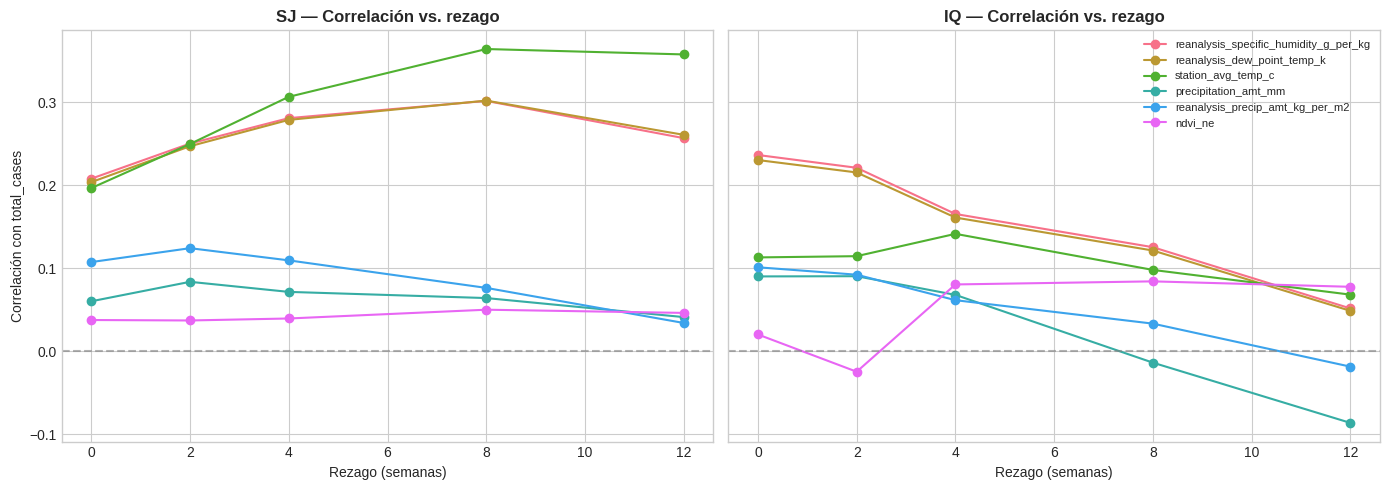

HALLAZGO CLAVE (evidencia del concept drift entre ciudades):
En SAN JUAN la correlación de temperatura/humedad con los casos SUBE con el rezago y
alcanza su máximo alrededor de 8-12 semanas (ej. station_avg_temp_c: 0.20 -> 0.36 -> 0.36).
En IQUITOS ocurre lo contrario: la correlación es más alta en rezago 0-2 y se DILUYE con el
rezago (ej. humedad específica: 0.24 -> 0.22 -> 0.05). La relación clima->transmisión no
tiene la misma forma en ambas ciudades: un solo modelo global, sin distinguir ciudad, estaría
promediando dos dinámicas distintas y probablemente ajustando mal a ambas.


In [8]:
# ── Visualización: cómo cambia la correlación clima-casos según el rezago, por ciudad ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, city in zip(axes, ['sj', 'iq']):
    tabla = tablas_lag[city]
    for f in tabla.index:
        ax.plot(lags, tabla.loc[f].values, marker='o', label=f)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
    ax.set_title(f'{city.upper()} — Correlación vs. rezago', fontweight='bold')
    ax.set_xlabel('Rezago (semanas)')
axes[0].set_ylabel('Correlación con total_cases')
axes[1].legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print("HALLAZGO CLAVE (evidencia del concept drift entre ciudades):")
print("En SAN JUAN la correlación de temperatura/humedad con los casos SUBE con el rezago y")
print("alcanza su máximo alrededor de 8-12 semanas (ej. station_avg_temp_c: 0.20 -> 0.36 -> 0.36).")
print("En IQUITOS ocurre lo contrario: la correlación es más alta en rezago 0-2 y se DILUYE con el")
print("rezago (ej. humedad específica: 0.24 -> 0.22 -> 0.05). La relación clima->transmisión no")
print("tiene la misma forma en ambas ciudades: un solo modelo global, sin distinguir ciudad, estaría")
print("promediando dos dinámicas distintas y probablemente ajustando mal a ambas.")


---
## Paso 6 — ¿San Juan e Iquitos son la misma población?

Comparamos directamente las distribuciones climáticas y de casos entre ambas ciudades para decidir si el modelado de la Fase 2 debe ser **por ciudad** o **conjunto con `city` como feature fuerte**.


     total_cases        reanalysis_specific_humidity_g_per_kg        \
            mean    std                                  mean   std   
city                                                                  
iq         7.570 10.770                                17.100 1.450   
sj        34.180 51.380                                16.550 1.560   

     reanalysis_dew_point_temp_k       station_avg_temp_c        \
                            mean   std               mean   std   
city                                                              
iq                       295.490 1.420             27.530 0.920   
sj                       295.110 1.570             27.010 1.420   

     precipitation_amt_mm        reanalysis_precip_amt_kg_per_m2         \
                     mean    std                            mean    std   
city                                                                      
iq                 64.250 35.220                          57.610 50.290   
sj      

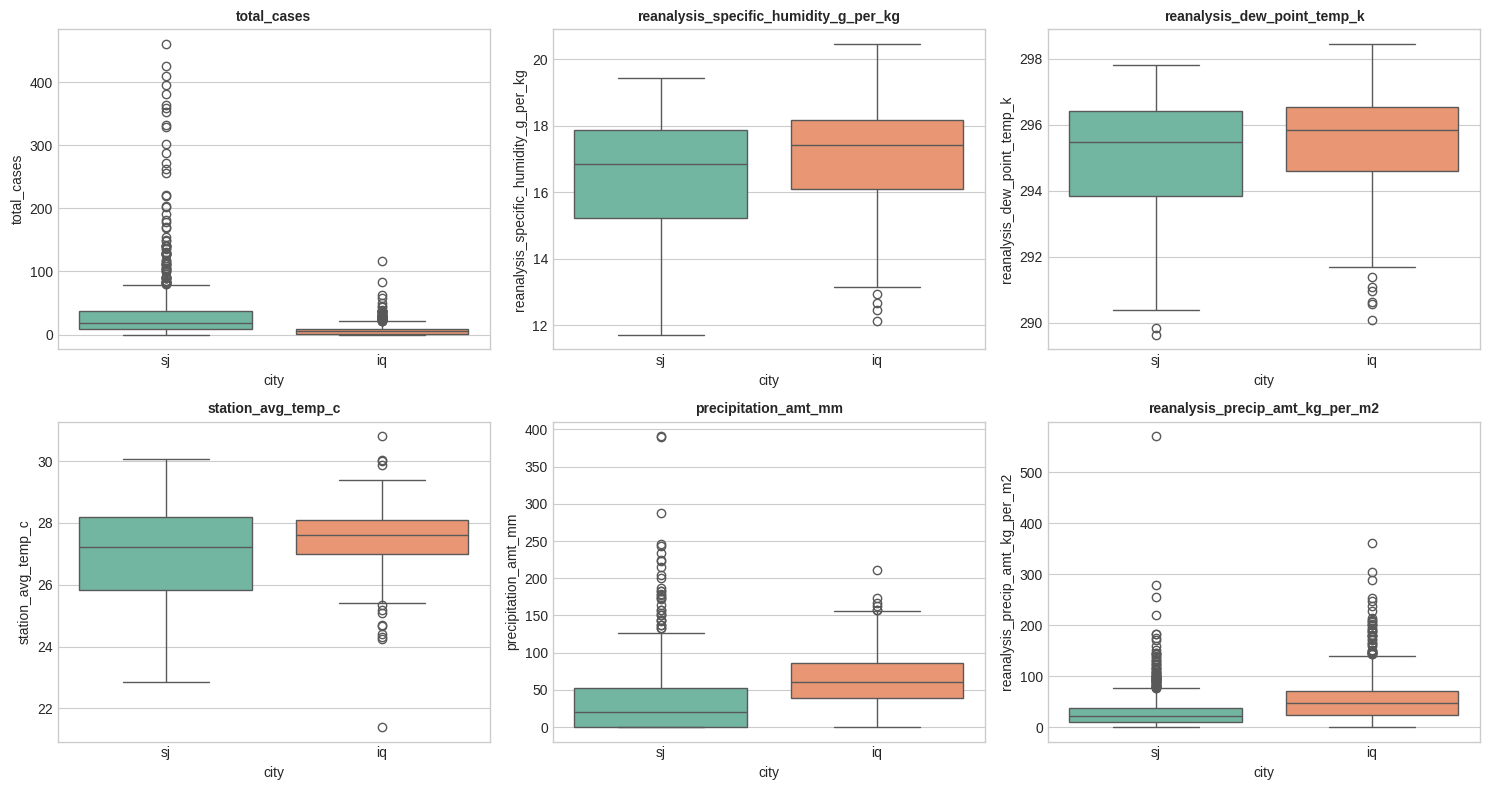


HALLAZGO: las medias y varianzas de temperatura, humedad y casos difieren claramente entre
ciudades (climas distintos: Caribe vs. Amazonía peruana). Confirma la decisión de tratar 'city'
como una variable estructural del modelo (a definir en Fase 2: modelos separados o 'city' como
feature categórica fuerte), y no simplemente promediar ambas series.


In [9]:
# ── Comparación directa sj vs iq ──
comparacion = df.groupby('city')[['total_cases'] + key_feats].agg(['mean','std']).round(2)
print(comparacion)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vars_plot = ['total_cases'] + key_feats[:5]
for ax, var in zip(axes.flat, vars_plot):
    sns.boxplot(data=df, x='city', y=var, ax=ax, palette='Set2')
    ax.set_title(var, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nHALLAZGO: las medias y varianzas de temperatura, humedad y casos difieren claramente entre")
print("ciudades (climas distintos: Caribe vs. Amazonía peruana). Confirma la decisión de tratar 'city'")
print("como una variable estructural del modelo (a definir en Fase 2: modelos separados o 'city' como")
print("feature categórica fuerte), y no simplemente promediar ambas series.")


---
## Paso 7 — Detección de Fuga de Datos Potencial (RAA2)

### Teoría: fuga de datos en problemas de series de tiempo

En datasets con estructura temporal, la fuga de datos aquí es **más sutil** y tiene que ver con **qué información existiría realmente en el momento de predecir**, y con **cómo se dividen y transforman los datos respecto al eje temporal**. A partir del EDA anterior, identificamos los siguientes riesgos concretos para este dataset:

| # | Riesgo de fuga | Por qué ocurre aquí | Mitigación para la Fase 2 |
|---|---|---|---|
| 1 | **Validación cruzada aleatoria (K-Fold)** en vez de temporal | `total_cases` tiene autocorrelación fuerte semana a semana (Paso 4); un K-Fold aleatorio pondría semanas "del futuro" en el fold de entrenamiento para predecir semanas "del pasado" en validación, inflando artificialmente la métrica | Usar `TimeSeriesSplit` o un split temporal explícito por fecha de corte, nunca `KFold` con `shuffle=True` |
| 2 | **Imputación de nulos con estadísticos globales** de toda la serie | El Paso 2 mostró que el % de nulos varía por año — imputar con la media de TODA la serie (pasado + futuro) filtra información del futuro hacia semanas pasadas | Imputar dentro del `Pipeline`/`ColumnTransformer`, ajustado solo con el fold de entrenamiento (igual lógica que el Práctico 5 con `StandardScaler`) |
| 3 | **Features de rezago (*lag features*) construidas hacia el futuro** | El Paso 5 mostró que el rezago óptimo es de varias semanas; al construir `feature.shift(k)` hay que verificar el signo: `shift(k)` con `k>0` trae el PASADO (correcto), `shift(-k)` traería el FUTURO (fuga directa) | Auditar explícitamente el signo de cada `shift()` antes de entrenar; test unitario simple: la fila `t` no debe poder ver ninguna fila con `week_start_date > t` |
| 4 | **Disponibilidad real de las variables de reanálisis (`reanalysis_*`) y NDVI en producción** | Estas variables provienen de productos de reanálisis climático y satelital (NOAA/NASA) que en la práctica se publican con **días o semanas de retraso** respecto a la fecha que describen — no son "tiempo real" aunque el dataset las presente alineadas por semana | Documentar en la Fase 3 qué variables tendría *realmente* disponibles el servicio de inferencia al momento de predecir, y no asumir que todo el vector de features del entrenamiento existirá sin retraso en producción |
| 5 | **Fuga entre ciudades al normalizar/escalar con estadísticos conjuntos** | El Paso 6 mostró que `sj` e `iq` tienen medias y varianzas distintas; un único `StandardScaler` ajustado sobre ambas ciudades mezcladas no es fuga de *target* pero sí una mala especificación que puede ocultar el verdadero comportamiento de cada ciudad | Evaluar escalar/modelar por ciudad, o al menos verificar el efecto de incluir `city` como feature explícita |

Ningún archivo de features contiene columnas del target (`total_cases`) — se verifica explícitamente a continuación — pero los riesgos anteriores son de **diseño del pipeline**, no de columnas contaminadas, y por eso son más fáciles de pasar por alto.


In [10]:
# ── Verificación explícita: ¿el archivo de features contiene el target o alguna proxy directa? ──
cols_sospechosas = [c for c in feat_train.columns if 'case' in c.lower() or 'target' in c.lower()]
print(f"Columnas sospechosas en dengue_features_train.csv: {cols_sospechosas if cols_sospechosas else 'ninguna (OK)'}")

# ── Verificación de alineación temporal (evita fuga por merge mal hecho) ──
chequeo = df.groupby('city').apply(lambda x: (x.sort_values('week_start_date')['week_start_date'].diff().dt.days.dropna() > 8).sum())
print(f"\nSemanas con salto temporal > 8 días entre filas consecutivas (posible desalineación), por ciudad:")
print(chequeo)

# ── Demostración del riesgo #3: signo correcto de un lag feature ──
demo = df[df['city']=='sj'].sort_values('week_start_date').reset_index(drop=True)[['week_start_date','station_avg_temp_c']].head(6)
demo['lag_correcto_shift(+2)'] = demo['station_avg_temp_c'].shift(2)   # trae el pasado -> OK
demo['fuga_shift(-2)'] = demo['station_avg_temp_c'].shift(-2)          # trae el futuro -> FUGA
print("\nDemostración del riesgo #3 (dirección del shift):")
print(demo)
print("\nEn 'lag_correcto_shift(+2)', la fila de 1990-04-30 recién tiene valor a partir de la 3ra fila")
print("(usa SOLO datos ya observados). En 'fuga_shift(-2)', la fila de 1990-04-30 YA muestra un valor")
print("tomado de dos semanas en el futuro -- ese es exactamente el patrón que hay que auditar en Fase 2.")


Columnas sospechosas en dengue_features_train.csv: ninguna (OK)

Semanas con salto temporal > 8 días entre filas consecutivas (posible desalineación), por ciudad:
city
iq    3
sj    4
dtype: int64

Demostración del riesgo #3 (dirección del shift):
  week_start_date  station_avg_temp_c  lag_correcto_shift(+2)  fuga_shift(-2)
0      1990-04-30              25.443                     NaN          26.714
1      1990-05-07              26.714                     NaN          27.471
2      1990-05-14              26.714                  25.443          28.943
3      1990-05-21              27.471                  26.714          28.114
4      1990-05-28              28.943                  26.714             NaN
5      1990-06-04              28.114                  27.471             NaN

En 'lag_correcto_shift(+2)', la fila de 1990-04-30 recién tiene valor a partir de la 3ra fila
(usa SOLO datos ya observados). En 'fuga_shift(-2)', la fila de 1990-04-30 YA muestra un valor
tomado de dos se

---
## Conclusiones de la Fase 1 y qué pasa a la Fase 2

### Hallazgos principales

| # | Hallazgo | Evidencia | Impacto para el modelado (Fase 2) |
|---|---|---|---|
| 1 | `total_cases` es un conteo muy asimétrico, con brotes extremos poco frecuentes | Skew ~4 en ambas ciudades (Paso 3) | Elegir un modelo robusto a colas largas; comparar MAE (error típico) y RMSE (penaliza brotes) en vez de mirar solo una métrica |
| 2 | Los nulos no son aleatorios en el tiempo, se concentran en ciertos años/variables (NDVI), y en SJ coinciden con el año del outbreak histórico (1994) | Paso 2 | Imputar dentro del pipeline, ajustado solo con el fold de entrenamiento — nunca con la media de toda la serie |
| 3 | La relación clima→casos es más fuerte con 8-12 semanas de rezago en SJ, y casi inmediata (y se diluye con el rezago) en IQ | Paso 5 | Construir *lag features* con el signo correcto y ventanas distintas por ciudad; la precipitación aporta poco, NDVI casi nada (candidato a bajo peso) |
| 4 | SJ e IQ tienen climas parecidos (humedad, temperatura, punto de rocío se superponen) pero una escala de casos muy distinta (media 4.5x mayor y desviación estándar 4.8x mayor en SJ) | Paso 6 | El clima solo no explica la diferencia de escala — reportar y evaluar métricas **por ciudad**, no solo agregadas, para que SJ no opaque el error de IQ en una métrica conjunta; tratar `city` como variable estructural |
| 5 | Los outbreaks no son anuales sino cíclicos (~3-5 años: SJ 1991-92, 1994, 1998, 2001, 2005, 2007-08; IQ 2002-03, 2004, 2008), consistente con la dinámica de múltiples serotipos del dengue | Paso 4 | El clima explica la estacionalidad *dentro* de un año, pero no por qué un año es un año de outbreak severo — límite honesto a documentar en el informe, no se resuelve solo con estas features |
| 6 | El dataset tiene un eje temporal real (1990-2010) con outbreaks extremos identificables, y los saltos de fecha detectados son un artefacto benigno de numeración ISO de fin de año, no huecos reales | Paso 4 y Paso 7 | Habilita un split temporal genuino para Fase 2/4 sin necesidad de simular drift artificialmente; confirma que la serie está íntegra para construir *lag features* con confianza |

### Riesgos de fuga de datos identificados (a evitar desde el diseño en Fase 2)

Ver tabla completa del Paso 7: validación cruzada temporal (no K-Fold aleatorio), imputación aislada por fold, dirección correcta de los `shift()` en features de rezago (verificado explícitamente en el Paso 7), disponibilidad real de variables de reanálisis/NDVI en producción, y tratamiento explícito de `city` como variable estructural — reforzado ahora por el hallazgo #4 de arriba: agregar métricas entre ciudades sin separarlas no es fuga de datos en sentido estricto, pero es una forma de "fuga de objetivo de negocio" (SJ domina la métrica y esconde el desempeño real en IQ).

### Siguiente paso

En la **Fase 2** construiremos el pipeline de modelado (`ColumnTransformer` + imputación + features de rezago + modelo) aplicando exactamente estas mitigaciones, con validación temporal robusta (`TimeSeriesSplit`, nunca K-Fold aleatorio), métricas reportadas por ciudad, y lo empaquetaremos de forma reproducible con `joblib`. Además, reservaremos explícitamente el ~20% más reciente de cada ciudad como un conjunto de "producción simulada" (con sus verdaderas etiquetas) que el modelo **nunca ve durante el entrenamiento** — ese conjunto es el que usaremos en la Fase 4 para medir drift real y degradación de desempeño, en vez de tener que simular el drift artificialmente.

---
*Práctico Final — MLOps Local con Monitoreo de Data Drift | Dataset: DengAI (San Juan e Iquitos) | Fases 0-1*